In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

In [2]:
results = pd.read_csv(
    r"C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Processed\forecast_results.csv"
)

print(results.shape)
results.head()

results['Timestamp'] = pd.to_datetime(
    results['Timestamp'],
    format='mixed',
    utc=True
)

results = results.sort_values(
    'Timestamp'
).reset_index(drop=True)

print(results.dtypes)

(4917, 3)
Timestamp        datetime64[ns, UTC]
Actual_1hr                   float64
Predicted_1hr                float64
dtype: object


In [3]:
# Forecast error
results['forecast_error'] = (
    results['Actual_1hr'] - results['Predicted_1hr']
).abs()
results.head()


,Timestamp,Actual_1hr,Predicted_1hr,forecast_error
0,2026-05-25 01:49:17.719000+00:00,1.0,1.474220,0.474220
1,2026-05-25 01:54:19.936000+00:00,1.0,1.967517,0.967517
2,2026-05-25 01:59:16.907000+00:00,1.0,1.909188,0.909188
3,2026-05-25 02:04:19.360000+00:00,1.0,1.257034,0.257034
4,2026-05-25 02:09:18.002000+00:00,1.0,1.832747,0.832747


In [4]:
df = pd.read_csv(
    r"C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Processed\cpu_features.csv"
)
print(df.shape)
df['ts'] = pd.to_datetime(
    df['ts'],
    format='mixed',
    utc=True
)
df = df.sort_values(
    ['host_id','ts']
)

(74252, 27)


In [5]:
SERVER_ID = 1
df = df[
    df['host_id'] == SERVER_ID
].copy()
SERVER_NAME = df['hostName'].iloc[0]
print("Server:", SERVER_NAME)
print(df.shape)

Server: 10.10.10.65
(24750, 27)


In [6]:
# Features for isolation forest
iso_features = [
    'cpu_usage_pct',
    'memory_usage_pct',
    'power_kw',
    'cpu_temp_c',
    'resource_stress_index'
]
X_iso = df[
    iso_features
]
print(X_iso.shape)

(24750, 5)


In [7]:
# Train isolation forest
iso_model = IsolationForest(
    n_estimators=300,
    contamination=0.001,
    random_state=42
)
iso_model.fit(
    X_iso
)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",300
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.001
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [8]:
# Predict anomalies
df['iso_label'] = (
    iso_model.predict(X_iso)
)
df['iso_anomaly'] = (
    df['iso_label'] == -1
)
print(
    "Total anomalies:",
    df['iso_anomaly'].sum()
)
print(
    df['iso_anomaly']
    .value_counts()
)

Total anomalies: 25
iso_anomaly
False    24725
True        25
Name: count, dtype: int64


In [9]:
# Exact timestamp table
anomaly_table = df[
    df['iso_anomaly']
].copy()
anomaly_table = anomaly_table[
    [
        'ts',
        'host_id',
        'hostName',
        'cpu_usage_pct',
        'memory_usage_pct',
        'power_kw',
        'cpu_temp_c',
        'resource_stress_index'
    ]
]
anomaly_table = anomaly_table.sort_values(
    'ts'
)
anomaly_table.head(50)

,ts,host_id,hostName,cpu_usage_pct,memory_usage_pct,power_kw,cpu_temp_c,resource_stress_index
57572,2026-04-14 06:38:21.481000+00:00,1,10.10.10.65,58.0,70.0,0.221,40,64.0
57609,2026-04-14 09:43:21.766000+00:00,1,10.10.10.65,88.0,70.0,0.221,38,79.0
57626,2026-04-14 11:08:21.525000+00:00,1,10.10.10.65,76.0,70.0,0.221,39,73.0
57627,2026-04-14 11:13:22.631000+00:00,1,10.10.10.65,58.0,70.0,0.220,40,64.0
57637,2026-04-14 12:03:25.323000+00:00,1,10.10.10.65,62.0,70.0,0.220,39,66.0
57841,2026-04-15 05:03:14.216000+00:00,1,10.10.10.65,77.0,70.0,0.220,40,73.5
57842,2026-04-15 05:08:22.344000+00:00,1,10.10.10.65,58.0,70.0,0.220,42,64.0
57852,2026-04-15 05:58:27.662000+00:00,1,10.10.10.65,86.0,70.0,0.221,42,78.0
57854,2026-04-15 06:08:14.107000+00:00,1,10.10.10.65,75.0,70.0,0.223,39,72.5
57855,2026-04-15 06:13:24.486000+00:00,1,10.10.10.65,51.0,70.0,0.220,41,60.5


In [13]:
import sys
!{sys.executable} -m pip install plotly

  Using cached plotly-6.8.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
Using cached plotly-6.8.0-py3-none-any.whl (9.9 MB)
Using cached narwhals-2.22.1-py3-none-any.whl (454 kB)

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhal

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# Interacive anomaly plot
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "browser"

anomalies = df[
    df['iso_anomaly']
].copy()
fig = go.Figure()
# CPU Line
fig.add_trace(
    go.Scatter(
        x=df['ts'],
        y=df['cpu_usage_pct'],
        mode='lines',
        name='CPU Usage',
        line=dict(
            width=1
        )
    )
)
# Anomaly Markers
fig.add_trace(
    go.Scatter(
        x=anomalies['ts'],
        y=anomalies['cpu_usage_pct'],
        mode='markers+text',
        name='Isolation Forest Anomaly',
        marker=dict(
            color='red',
            size=12,
            line=dict(
                color='black',
                width=1
            )
        ),
        text=[
            ts.strftime(
                "%d-%m-%Y %H:%M"
            )
            for ts in anomalies['ts']
        ],
        textposition="top center",
        hovertemplate=
        "<b>Timestamp:</b> %{text}<br>" +
        "<b>CPU:</b> %{y:.2f}%<br>" +
        "<extra></extra>"
    )
)
fig.update_layout(
    title=
    f"{SERVER_NAME} | Isolation Forest CPU Anomalies",
    xaxis_title="Timestamp",
    yaxis_title="CPU Usage (%)",
    hovermode='closest',
    height=800
)
fig.show()

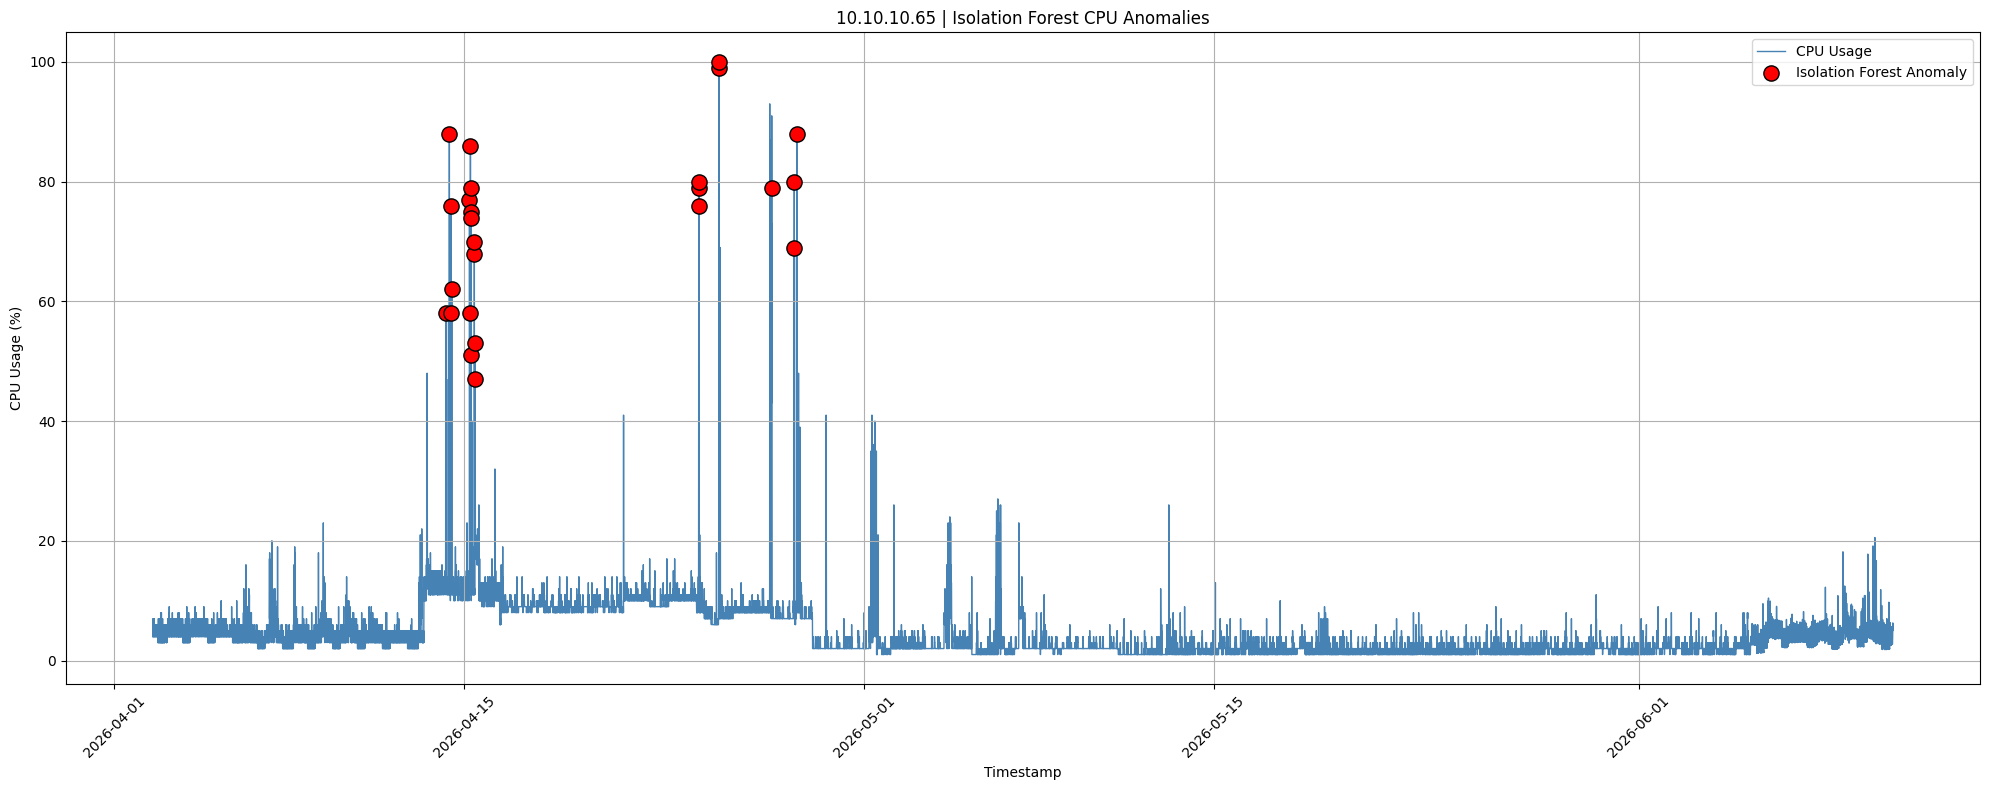

In [10]:
# Clean anomaly plot
plt.figure(
    figsize=(20,8)
)
# CPU line
plt.plot(
    df['ts'],
    df['cpu_usage_pct'],
    color='steelblue',
    linewidth=1,
    label='CPU Usage',
    zorder=1
)
# Anomaly markers
plt.scatter(
    df.loc[
        df['iso_anomaly'],
        'ts'
    ],
    df.loc[
        df['iso_anomaly'],
        'cpu_usage_pct'
    ],
    color='red',
    marker='o',
    s=120,
    edgecolors='black',
    linewidths=1,
    zorder=20,
    label='Isolation Forest Anomaly'
)
plt.title(
    f'{SERVER_NAME} | Isolation Forest CPU Anomalies'
)
plt.xlabel(
    'Timestamp'
)
plt.ylabel(
    'CPU Usage (%)'
)
plt.legend()
plt.grid(True)
plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()